#### Výsledkom tohto súboru DIPLOMOVKA_1.časť.ipynb je dataset s názvom final_dataset_PART1.csv, ktorý použijeme v Analytickom procese v prvej časti, teda obsahuje aj pacientov, ktorí zomreli z iných príčin ako na rakovinu prsníka


#### Inštalácie a importovania knižníc

In [1]:
!pip install lifelines
!pip install shap

!pip install imbalanced-learn


  Preparing metadata (setup.py) ... done
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4090 sha256=abdebcbdf1ded2fc10ec9f07e1250c229d937442c4f6d522c0a598a1f46a7b72
  Stored in directory: /home/jovyan/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 967.3/967.3 kB 42.0 MB/s eta 0:00:00


In [2]:
pip install --upgrade seaborn pandas matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 84.1 MB/s eta 0:00:00
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0
Note: you may need to restart the kernel to use updated packages.


In [3]:
!pip uninstall numpy -y


Found existing installation: numpy 2.1.3
Uninstalling numpy-2.1.3:
  Successfully uninstalled numpy-2.1.3


In [4]:
!pip install numpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 93.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.61.0 requires numpy<2.2,>=1.24, but you have numpy 2.2.4 which is incompatible.


In [5]:
!pip install numpy==1.26.0


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.9/17.9 MB 95.3 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.4
    Uninstalling numpy-2.2.4:
      Successfully uninstalled numpy-2.2.4


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)


In [2]:
from scipy.stats import mode
from sklearn import datasets, tree
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (roc_auc_score, confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score,
                             classification_report)

In [3]:


from imblearn.over_sampling import SMOTE
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.utils import concordance_index



In [4]:
import matplotlib.pyplot as plt
import seaborn as sns


In [94]:
#Nacitanie suboru udajov Breast Cancer METABRIC.csv
df_metabric =pd.read_csv("Breast Cancer METABRIC.csv")

#Zobrazenie rozmerov suboru udajov, dataset ma 2509 zaznamov popisanych 34 atributmi
print(f'METABRIC Dataset Shape: {df_metabric.shape}')
print(f'METABRIC Dataset Memory Usage: {df_metabric.memory_usage().sum() / 1024 ** 2:.2f} MB')

METABRIC Dataset Shape: (2509, 34)
METABRIC Dataset Memory Usage: 0.65 MB


In [95]:
#tu mozeme vidiet, ze subor udajov obsahuje aj pacientov, ktori zomreli na rakovinu aj pacientov ktori zomreli z inych pricin
df_metabric["Patient's Vital Status"].value_counts()


Patient's Vital Status
Living                  837
Died of Disease         646
Died of Other Causes    497
Name: count, dtype: int64

In [96]:
df_metabric.head()

,Patient ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,Cohort,ER status measured by IHC,ER Status,Neoplasm Histologic Grade,HER2 status measured by SNP6,HER2 Status,Tumor Other Histologic Subtype,Hormone Therapy,Inferred Menopausal State,Integrative Cluster,Primary Tumor Laterality,Lymph nodes examined positive,Mutation Count,Nottingham prognostic index,Oncotree Code,Overall Survival (Months),Overall Survival Status,PR Status,Radio Therapy,Relapse Free Status (Months),Relapse Free Status,Sex,3-Gene classifier subtype,Tumor Size,Tumor Stage,Patient's Vital Status
0,MB-0000,75.65,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,No,claudin-low,1.0,Positve,Positive,3.0,Neutral,Negative,Ductal/NST,Yes,Post,4ER+,Right,10.0,NaN,6.044,IDC,140.500000,Living,Negative,Yes,138.65,Not Recurred,Female,ER-/HER2-,22.0,2.0,Living
1,MB-0002,43.19,Breast Conserving,Breast Cancer,Breast Invasive Ductal Carcinoma,High,No,LumA,1.0,Positve,Positive,3.0,Neutral,Negative,Ductal/NST,Yes,Pre,4ER+,Right,0.0,2.0,4.020,IDC,84.633333,Living,Positive,Yes,83.52,Not Recurred,Female,ER+/HER2- High Prolif,10.0,1.0,Living
2,MB-0005,48.87,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,High,Yes,LumB,1.0,Positve,Positive,2.0,Neutral,Negative,Ductal/NST,Yes,Pre,3,Right,1.0,2.0,4.030,IDC,163.700000,Deceased,Positive,No,151.28,Recurred,Female,NaN,15.0,2.0,Died of Disease
3,MB-0006,47.68,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,Yes,LumB,1.0,Positve,Positive,2.0,Neutral,Negative,Mixed,Yes,Pre,9,Right,3.0,1.0,4.050,MDLC,164.933333,Living,Positive,Yes,162.76,Not Recurred,Female,NaN,25.0,2.0,Living
4,MB-0008,76.97,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,Yes,LumB,1.0,Positve,Positive,3.0,Neutral,Negative,Mixed,Yes,Post,9,Right,8.0,2.0,6.080,MDLC,41.366667,Deceased,Positive,Yes,18.55,Recurred,Female,ER+/HER2- High Prolif,40.0,2.0,Died of Disease


### Vykreslenie grafu, ktorý zobrazuje chýbajúce hodnoty v súbore údajov

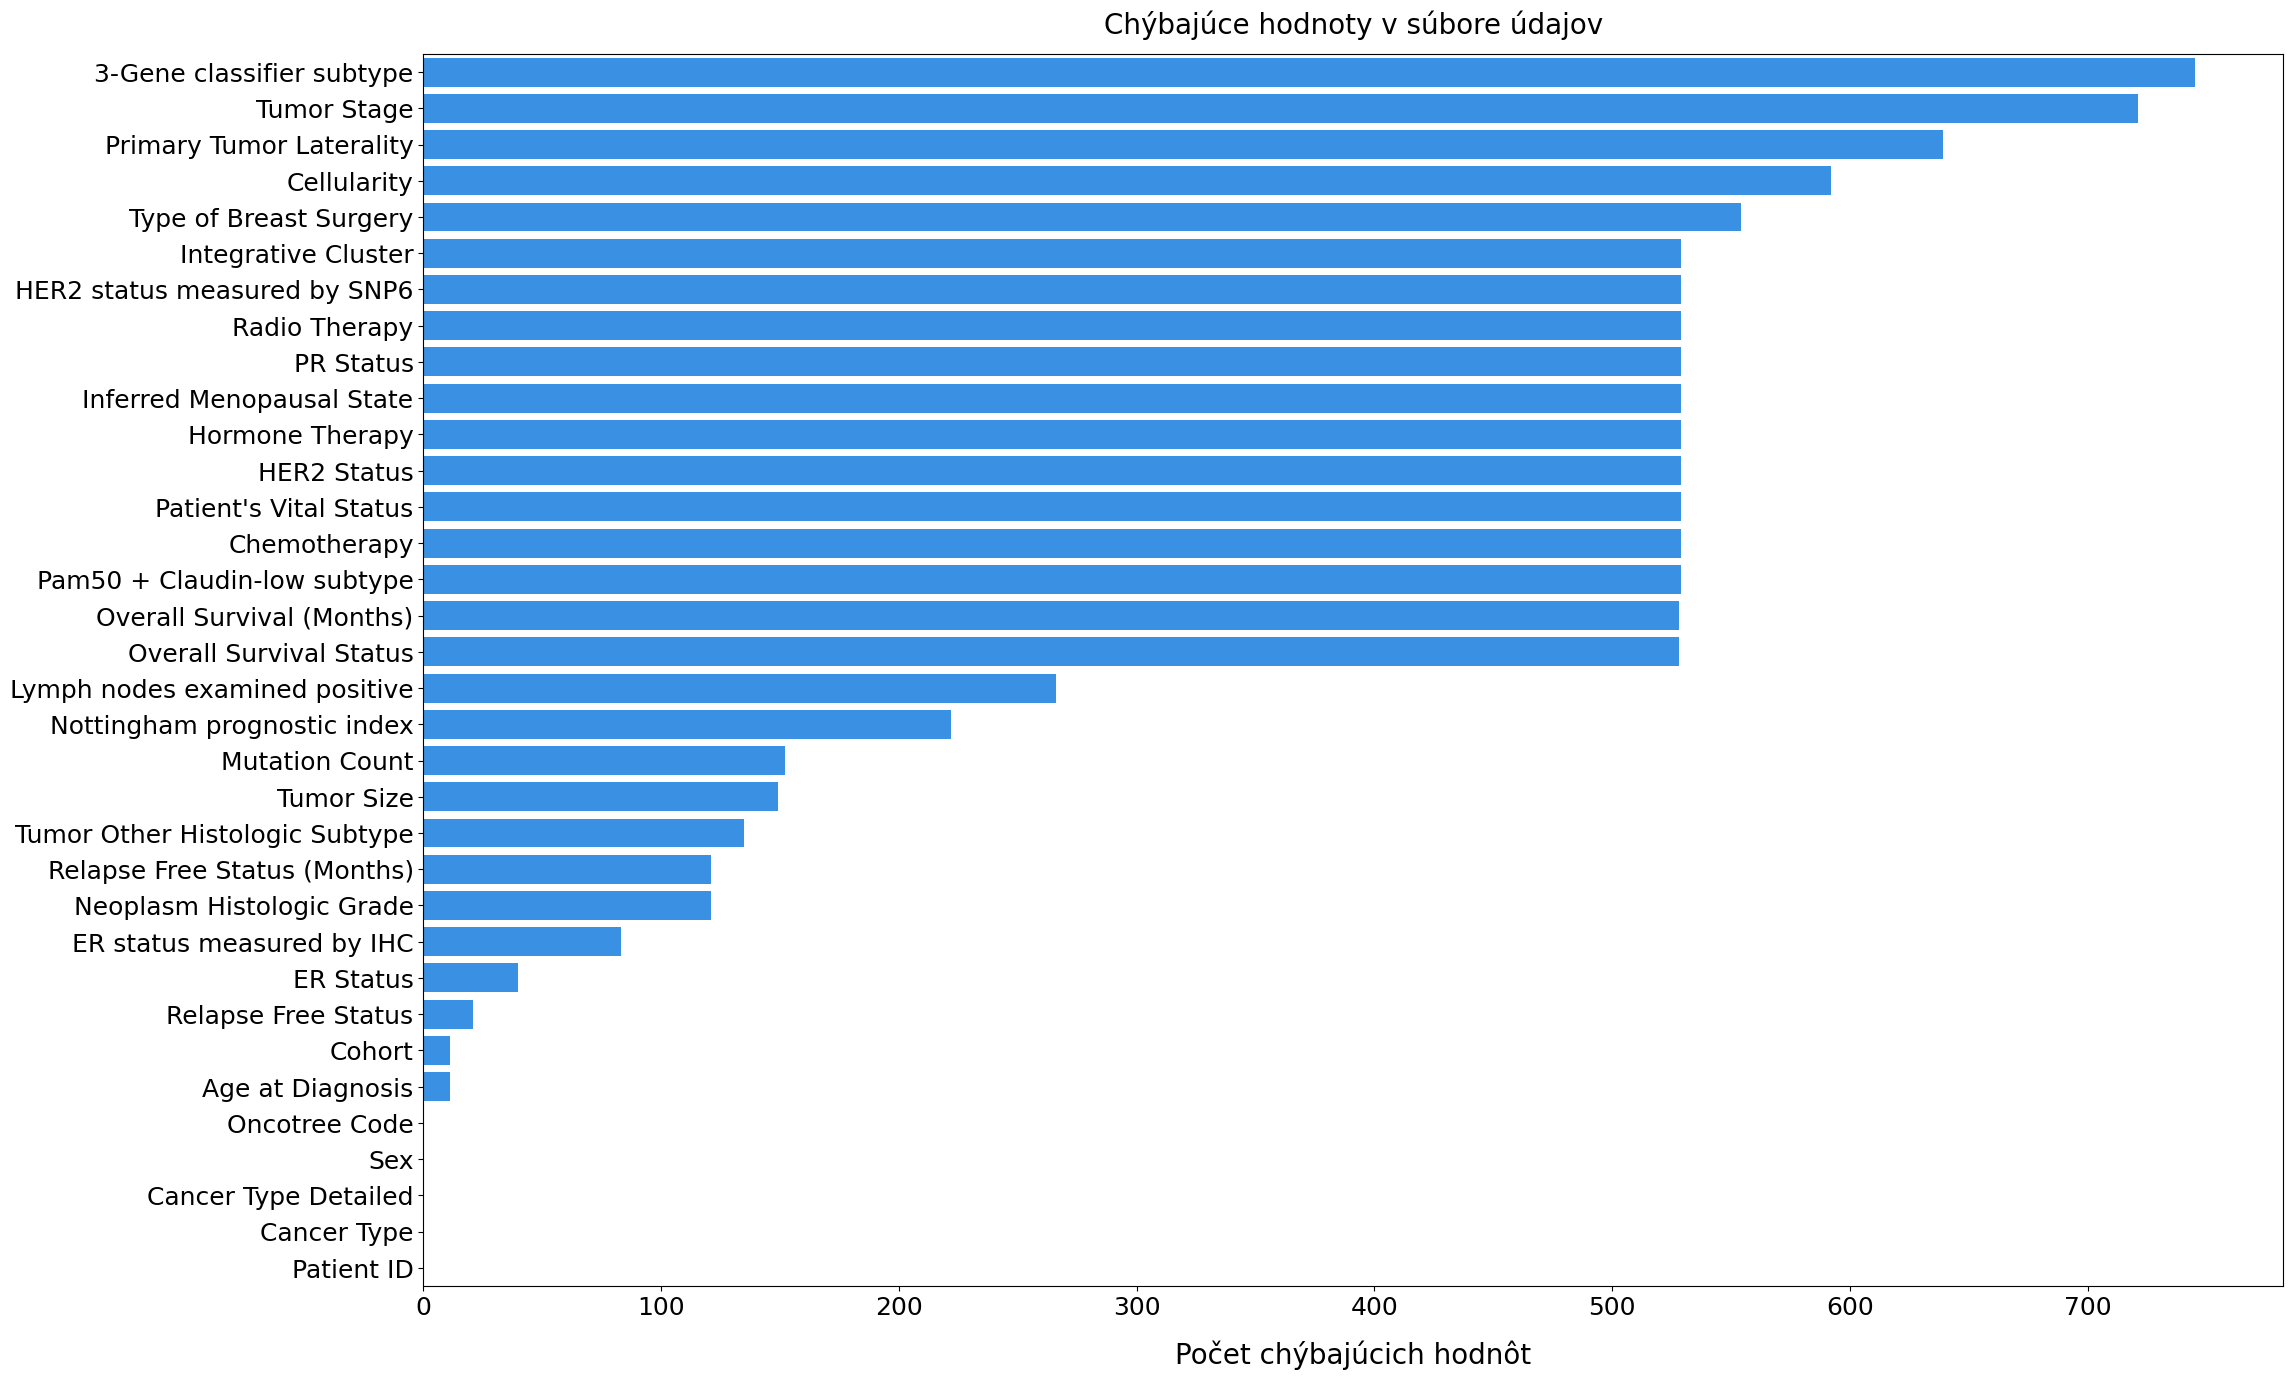

In [97]:
#Vidime ze vacsina atributov ma dost vela chybajucich hodnot
fig = plt.figure(figsize=(24, 16))
sns.barplot(
    x=df_metabric.isnull().sum().sort_values(ascending=False).values,
    y=df_metabric.isnull().sum().sort_values(ascending=False).index,
    color="#1E90FF"  
)

plt.xlabel('Počet chýbajúcich hodnôt', size=20, labelpad=15)
plt.ylabel('')
plt.tick_params(axis='x', labelsize=18)
plt.tick_params(axis='y', labelsize=18)
plt.title('Chýbajúce hodnoty v súbore údajov', size=20, pad=15)
plt.show()

In [98]:
data = df_metabric 

### Vizualizacie, distribucie hodnot niektorych atributov pred doplnanim chybajucich hodnot

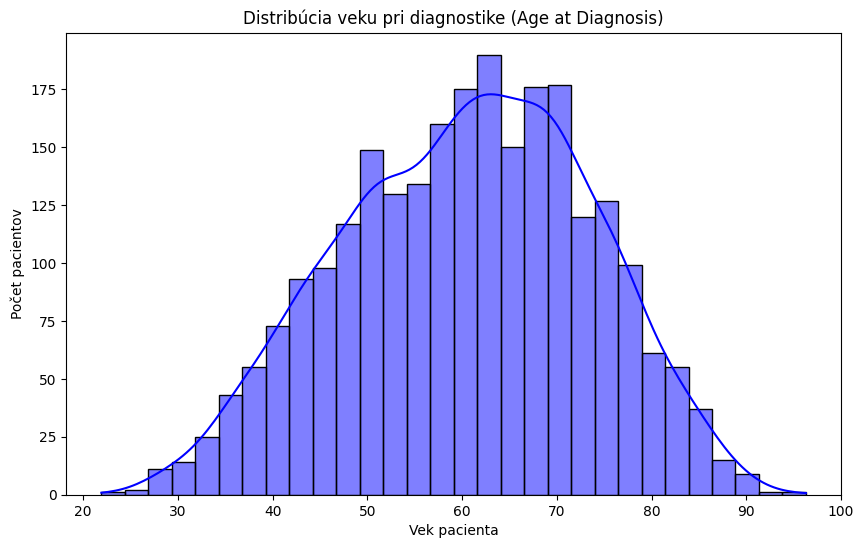

In [99]:
plt.figure(figsize=(10, 6))
sns.histplot(data['Age at Diagnosis'], kde=True, color='blue', bins=30)
plt.title('Distribúcia veku pri diagnostike (Age at Diagnosis)')
plt.xlabel('Vek pacienta')
plt.ylabel('Počet pacientov')
plt.show()


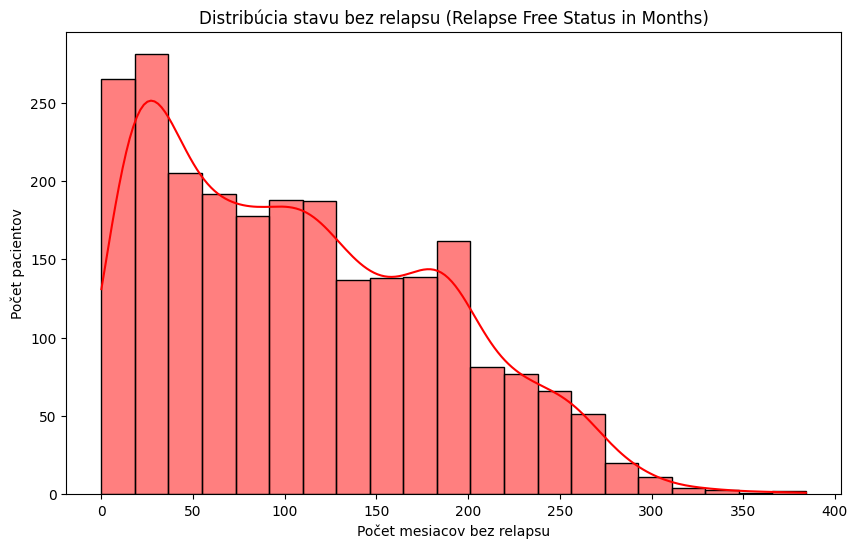

In [100]:
plt.figure(figsize=(10, 6))
sns.histplot(data['Relapse Free Status (Months)'], kde=True, color='red')  
plt.title('Distribúcia stavu bez relapsu (Relapse Free Status in Months)')
plt.xlabel('Počet mesiacov bez relapsu')
plt.ylabel('Počet pacientov')

plt.show()


### Chubajuce hodnoty
#### V nasledujucej casti sa budeme venovat doplnaniu chybajucich hodnot
##### K doplnaniu chybajucich hodnot sme pristupovali velmi citlivo, kedze su to medinske data a snazili sme sa vyhnut pripadnemu skresleniu

In [101]:
# Odstráni 21 riadky, kde je chýbajúca hodnota v stĺpci 'Relapse Free Status'
data = data.dropna(subset=['Relapse Free Status'])


In [102]:
#Tento kód nahradí chýbajúce hodnoty v atribúte Relapse Free Status (Months) pomocou priemeru v rámci každej kombinácie Cancer Type Detailed a Relapse Free Status
data['Relapse Free Status (Months)'] = data.groupby(['Cancer Type Detailed', 'Relapse Free Status'])['Relapse Free Status (Months)'].transform(lambda x: x.fillna(x.mean()))


In [103]:
# Doplnenie chýbajúcich hodnnôt v atribute Overall Survival Status podľa Cancer Type Detailed a Relapse Free Status najcastejsou hodnotou 
data['Overall Survival Status'] = data.groupby(['Cancer Type Detailed', 'Relapse Free Status'])['Overall Survival Status'].transform(lambda x: x.fillna(x.mode()[0]))

In [104]:
# rovnakym principom ako sme doplnili chybajuce hodnoty v atribute Relapse Free Status (Months) doplnime chybajuce hodnoty aj v atribute Overall Survival Status (Months)
data['Overall Survival (Months)'] = data.groupby(['Cancer Type Detailed', 'Overall Survival Status'])['Overall Survival (Months)'].transform(lambda x: x.fillna(x.mean()))


In [105]:
# Nahradenie chýbajúcich hodnôt v 'ER status measured by IHC' celkovou najčastejšou hodnotou
data['ER status measured by IHC'] = data['ER status measured by IHC'].transform(lambda x: x.fillna(x.mode()[0]))


In [106]:
x = data['ER Status'].isna().sum()
print(f"Počet chýbajúcich hodnôt v atribúte 'ER status measured by IHC': {x}")


Počet chýbajúcich hodnôt v atribúte 'ER status measured by IHC': 29


In [107]:
# Doplnenie chýbajúcich hodnôt ER Status najčastejšou hodnotou v ramci Cancer Type Detailed
data['ER Status'] = data.groupby('Cancer Type Detailed')['ER Status'].transform(lambda x: x.fillna(x.mode()[0]))

In [108]:
# Opat Doplnenie HER2 Status najčastejšou hodnotou na základe skupiny  Cancer Type Detailed
data['HER2 Status'] = data.groupby('Cancer Type Detailed')['HER2 Status'].transform(lambda x: x.fillna(x.mode()[0]))


In [109]:
# Nahradenie chýbajúcich hodnôt v 'HER2 status measured by SNP6' celkovým modusom
data['HER2 status measured by SNP6'] = data['HER2 status measured by SNP6'].transform(lambda x: x.fillna(x.mode()[0]))


In [110]:
# Doplníme chýbajúce hodnoty pre Chemotherapy
data['Chemotherapy'] = data.groupby('Cancer Type Detailed')['Chemotherapy'].transform(lambda x: x.fillna(x.mode()[0]))

# Doplníme chýbajúce hodnoty pre PR Status
data['PR Status'] = data.groupby('Cancer Type Detailed')['PR Status'].transform(lambda x: x.fillna(x.mode()[0]))

# Doplníme chýbajúce hodnoty pre Hormone Therapy
data['Hormone Therapy'] = data.groupby('Cancer Type Detailed')['Hormone Therapy'].transform(lambda x: x.fillna(x.mode()[0]))

# Doplníme chýbajúce hodnoty pre Radio Therapy
data['Radio Therapy'] = data.groupby('Cancer Type Detailed')['Radio Therapy'].transform(lambda x: x.fillna(x.mode()[0]))

In [111]:
# Doplníme chýbajúce hodnoty pre Age at Diagnosis
data['Age at Diagnosis'] = data.groupby('Cancer Type Detailed')['Age at Diagnosis'].transform(lambda x: x.fillna(x.mode()[0]))

# Doplníme chýbajúce hodnoty pre Cohort
data['Cohort'] = data.groupby('Cancer Type Detailed')['Cohort'].transform(lambda x: x.fillna(x.mode()[0]))

# Doplníme chýbajúce hodnoty pre Cellularity
data['Cellularity'] = data.groupby('Cancer Type Detailed')['Cellularity'].transform(lambda x: x.fillna(x.mode()[0]))

In [112]:
data['Type of Breast Surgery'] = data.groupby('Cancer Type Detailed')['Type of Breast Surgery'].transform(lambda x: x.fillna(x.mode()[0]))


In [113]:
# Doplníme chýbajúce hodnoty pre Pam50 + Claudin-low subtype
data['Pam50 + Claudin-low subtype'] = data.groupby('Cancer Type Detailed')['Pam50 + Claudin-low subtype'].transform(lambda x: x.fillna(x.mode()[0]))

In [114]:
# Doplníme chýbajúce hodnoty pre Neoplasm Histologic Grade

data['Neoplasm Histologic Grade'] = data.groupby('Cancer Type Detailed')['Neoplasm Histologic Grade'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
    
)


In [115]:
x = data['Neoplasm Histologic Grade'].isna().sum()
print(f"Počet chýbajúcich hodnôt v atribúte 'Neoplasm Histologic Grade': {x}")


Počet chýbajúcich hodnôt v atribúte 'Neoplasm Histologic Grade': 4


In [116]:
# Vypiseme si pocet chybajucich hodnot v ramci atributu 'Tumor Other Histologic Subtype'
tumor_other_histologic_subtype_counts = data['Tumor Other Histologic Subtype'].value_counts()
print(tumor_other_histologic_subtype_counts)


Tumor Other Histologic Subtype
Ductal/NST             1805
Mixed                   267
Lobular                 191
Medullary                32
Mucinous                 25
Tubular/ cribriform      23
Other                    21
Metaplastic               2
Name: count, dtype: int64


In [117]:
# Nahradenie chýbajúcich hodnôt Tumor Other Histologic Subtype podla Cancer Type Detailed najčastejšou hodnotou
data['Tumor Other Histologic Subtype'] = (
    data.groupby('Cancer Type Detailed')['Tumor Other Histologic Subtype']
    .transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Ductal/NST'))
)

In [118]:
missing_values = data['Inferred Menopausal State'].isnull().sum()
print(f"Počet chýbajúcich hodnôt v atribúte 'Inferred Menopausal State': {missing_values}")


Počet chýbajúcich hodnôt v atribúte 'Inferred Menopausal State': 509


In [119]:
# Tu sme doplnili chybajuce hodnoty na zaklade veku pacienta, ked ma pacient <= 50 je v Pre menopauzalnom obdobi naopak ak ma >50 rokov je v Post menopauzalnom obdobi
data['Inferred Menopausal State'] = data.apply(
    lambda row: 'Pre' if pd.isnull(row['Inferred Menopausal State']) and row['Age at Diagnosis'] <= 50 else 
               ('Post' if pd.isnull(row['Inferred Menopausal State']) and row['Age at Diagnosis'] > 50 else row['Inferred Menopausal State']),
    axis=1
)

In [120]:
cancer_type = data['Inferred Menopausal State'].value_counts()
print(cancer_type)

Inferred Menopausal State
Post    1919
Pre      569
Name: count, dtype: int64


In [121]:
data['Integrative Cluster'] = data.groupby('Cancer Type Detailed')['Integrative Cluster'].transform(lambda x: x.fillna(x.mode()[0]))

In [122]:
data['Tumor Other Histologic Subtype'] = data.groupby('Cancer Type Detailed')['Tumor Other Histologic Subtype'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)


In [123]:
# Vypiseme si opat pocet chybajucich hodnot v ramci atributu 'Tumor Other Histologic Subtype'
tumor_other_histologic_subtype_counts = data['Tumor Other Histologic Subtype'].value_counts()
print(tumor_other_histologic_subtype_counts)


Tumor Other Histologic Subtype
Ductal/NST             1927
Mixed                   267
Lobular                 191
Medullary                32
Mucinous                 25
Tubular/ cribriform      23
Other                    21
Metaplastic               2
Name: count, dtype: int64


In [124]:
# Nahradenie zvyšných chýbajúcich hodnôt hodnotou 'Ductal/NST', ako najčastejšie sa vyskytujúcou hodnotu 
data['Tumor Other Histologic Subtype'].fillna('Ductal/NST', inplace=True)

In [125]:
data['Primary Tumor Laterality'] = data.groupby(['Cancer Type Detailed'])['Primary Tumor Laterality'].transform(lambda x: x.fillna(x.mode()[0]))


In [126]:
# Tento kod vypočíta najčastejšiu hodnotu cize modus v stĺpci "Lymph nodes examined positive" pre každú skupinu podľa atributu "Cancer Type Detailed"
# a napriklad v pripade Breast Angiosarcoma neexistuje modus, preto vrati Nan
mode_per_group = data.groupby('Cancer Type Detailed')['Lymph nodes examined positive'].apply(lambda x: x.mode()[0] if not x.mode().empty else None)

# Výpis výsledkov
print(mode_per_group)


Cancer Type Detailed
Breast                                       0.0
Breast Angiosarcoma                          NaN
Breast Invasive Ductal Carcinoma             0.0
Breast Invasive Lobular Carcinoma            0.0
Breast Invasive Mixed Mucinous Carcinoma     0.0
Breast Mixed Ductal and Lobular Carcinoma    0.0
Invasive Breast Carcinoma                    0.0
Metaplastic Breast Cancer                    0.0
Name: Lymph nodes examined positive, dtype: float64


In [127]:
# Početnosť hodnôt v stĺpci 'Lymph nodes examined positive' v datasete
frequency = data['Lymph nodes examined positive'].value_counts()

print(frequency)


Lymph nodes examined positive
0.0     1182
1.0      379
2.0      189
3.0      127
4.0       63
6.0       51
5.0       49
7.0       29
8.0       22
9.0       18
14.0      17
10.0      14
11.0      14
16.0      11
15.0      10
12.0       9
13.0       7
18.0       6
17.0       5
19.0       4
22.0       4
20.0       3
21.0       3
25.0       2
23.0       2
24.0       2
41.0       1
26.0       1
31.0       1
33.0       1
45.0       1
30.0       1
Name: count, dtype: int64


#### Pri atribúte Lymph nodes examined positive a potom aj ďalších som narazila na problém, že ak som chcela doplniť hodnoty najčastejšou hodnotou v rámci danej cancer type detailed, tak v prípade Breast Angiosarcoma tam bola Nan hodnota preto to ošetríme tak, že to nahradíme najčastejšou hodnotou v rámci daného cancer type detailed a potom ten zvyšok v tomto prípade Breast Angiosarcoma doplníme najčastejšou hodnotou v rámci daného celého stĺpca


In [128]:
# Nahradenie NaN hodnot v rámci každého 'Cancer Type Detailed' pomocou módu
data['Lymph nodes examined positive'] = data.groupby('Cancer Type Detailed')['Lymph nodes examined positive'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
)

# Ak stále existujú NaN hodnoty, nahradiť ich najčastejšou hodnotou v celom stĺpci
data['Lymph nodes examined positive'] = data['Lymph nodes examined positive'].fillna(data['Lymph nodes examined positive'].mode()[0])


In [129]:
# vypočíta najčastejšiu hodnotu cize modus v stĺpci "Mutation Count" pre každú skupinu podľa atributu "Cancer Type Detailed"
mode_per_group = data.groupby('Cancer Type Detailed')['Mutation Count'].apply(lambda x: x.mode()[0] if not x.mode().empty else None)

print(mode_per_group)


Cancer Type Detailed
Breast                                       4.0
Breast Angiosarcoma                          NaN
Breast Invasive Ductal Carcinoma             5.0
Breast Invasive Lobular Carcinoma            2.0
Breast Invasive Mixed Mucinous Carcinoma     6.0
Breast Mixed Ductal and Lobular Carcinoma    5.0
Invasive Breast Carcinoma                    4.0
Metaplastic Breast Cancer                    6.0
Name: Mutation Count, dtype: float64


In [130]:
# Nahradenie NaN hodnot v rámci každého 'Cancer Type Detailed' pomocou módu
data['Mutation Count'] = data.groupby('Cancer Type Detailed')['Mutation Count'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
)

# Ak stále existujú NaN hodnoty, nahradiť ich najčastejšou hodnotou v celom stĺpci
data['Mutation Count'] = data['Mutation Count'].fillna(data['Mutation Count'].mode()[0])




# TUMOR STAGE atribut

### vidíme, že počet chýbajúcich hodnôt celkovo je 721 a že najviac chýbajúcich hodnôt je pri Breast Invasive Ductal Carcinoma

In [131]:
missing_values_tumor_stage = data['Tumor Stage'].isna().sum()
print(f"Počet chýbajúcich hodnôt v atribúte 'Tumor Stage': {missing_values_tumor_stage}")


Počet chýbajúcich hodnôt v atribúte 'Tumor Stage': 721


In [132]:
missing_values_by_cancer_type = data.groupby('Cancer Type Detailed')['Tumor Stage'].apply(lambda x: x.isna().sum())
print(missing_values_by_cancer_type)


Cancer Type Detailed
Breast                                         9
Breast Angiosarcoma                            0
Breast Invasive Ductal Carcinoma             554
Breast Invasive Lobular Carcinoma             58
Breast Invasive Mixed Mucinous Carcinoma       6
Breast Mixed Ductal and Lobular Carcinoma     47
Invasive Breast Carcinoma                     46
Metaplastic Breast Cancer                      1
Name: Tumor Stage, dtype: int64


In [133]:
unique_cancer_types = data['Tumor Stage'].unique()
print(unique_cancer_types)


[ 2.  1.  4.  3.  0. nan]


In [134]:
# Najčastejšia hodnota 'Tumor Stage' v rámci 'Cancer Type Detailed'
mode_tumor_stage = data.groupby('Cancer Type Detailed')['Tumor Stage'].apply(lambda x: x.mode()[0])

# Priemerná hodnota 'Tumor Stage' v rámci 'Cancer Type Detailed'
mean_tumor_stage = data.groupby('Cancer Type Detailed')['Tumor Stage'].apply(lambda x: x.mean())

# Výpis výsledkov
print("Najčastejšia hodnota 'Tumor Stage' v rámci 'Cancer Type Detailed':")
print(mode_tumor_stage)
print("\nPriemerná hodnota 'Tumor Stage' v rámci 'Cancer Type Detailed':")
print(mean_tumor_stage)


Najčastejšia hodnota 'Tumor Stage' v rámci 'Cancer Type Detailed':
Cancer Type Detailed
Breast                                       1.0
Breast Angiosarcoma                          0.0
Breast Invasive Ductal Carcinoma             2.0
Breast Invasive Lobular Carcinoma            2.0
Breast Invasive Mixed Mucinous Carcinoma     1.0
Breast Mixed Ductal and Lobular Carcinoma    2.0
Invasive Breast Carcinoma                    1.0
Metaplastic Breast Cancer                    1.0
Name: Tumor Stage, dtype: float64

Priemerná hodnota 'Tumor Stage' v rámci 'Cancer Type Detailed':
Cancer Type Detailed
Breast                                       1.583333
Breast Angiosarcoma                          0.500000
Breast Invasive Ductal Carcinoma             1.748851
Breast Invasive Lobular Carcinoma            1.804511
Breast Invasive Mixed Mucinous Carcinoma     1.368421
Breast Mixed Ductal and Lobular Carcinoma    1.686364
Invasive Breast Carcinoma                    1.445946
Metaplastic Breast Can

#### chybajuce hodnoty sme doplnili modusom cize najcastejsou hodnotou 

In [135]:
print(data[['Cancer Type Detailed', 'Tumor Stage']].isna().sum())


# Nahradenie NaN hodnot v rámci každého 'Cancer Type Detailed' pomocou módu
data['Tumor Stage'] = data.groupby('Cancer Type Detailed')['Tumor Stage'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
)

# Ak stále existujú NaN hodnoty, nahradiť ich najčastejšou hodnotou v celom stĺpci
data['Tumor Stage'] = data['Tumor Stage'].fillna(data['Tumor Stage'].mode()[0])


Cancer Type Detailed      0
Tumor Stage             721
dtype: int64


# TUMOR SIZE

In [136]:
missing_values_tumor_size = data['Tumor Size'].isna().sum()
print(f"Počet chýbajúcich hodnôt v atribúte 'Tumor Size': {missing_values_tumor_size}")


Počet chýbajúcich hodnôt v atribúte 'Tumor Size': 138


In [137]:
missing_values_by_cancer_type = data.groupby('Cancer Type Detailed')['Tumor Size'].apply(lambda x: x.isna().sum())
print(missing_values_by_cancer_type)


Cancer Type Detailed
Breast                                        0
Breast Angiosarcoma                           2
Breast Invasive Ductal Carcinoma             85
Breast Invasive Lobular Carcinoma            12
Breast Invasive Mixed Mucinous Carcinoma      2
Breast Mixed Ductal and Lobular Carcinoma     6
Invasive Breast Carcinoma                    30
Metaplastic Breast Cancer                     1
Name: Tumor Size, dtype: int64


In [138]:
unique_cancer_types = data['Tumor Size'].unique()
print(unique_cancer_types)


[ 22.    10.    15.    25.    40.    31.    65.    29.    34.    16.
  28.    21.    19.    36.    33.    23.    17.    18.    12.    50.
  24.    13.    14.    55.    30.    39.    70.    45.    27.   150.
  60.    26.    20.     9.    35.    80.    38.     2.    52.    44.
  48.     3.     5.    46.    11.      nan  53.    47.    32.    67.
  43.    42.   180.    57.     4.   100.    37.    90.     8.   160.
  84.   130.     5.5   62.     1.    49.    99.    68.     7.    41.
   6.    75.    51.   120.    61.    79.    71.    22.5   17.9   14.5
  12.8   18.5   15.5   21.5   16.9   24.4   12.5   40.3   11.8   32.6
  17.2   13.8   15.7  182.    85.    18.3   21.6   28.5   16.2    2.3
  15.2   31.1   14.3   12.6   25.1   17.6    2.12  21.3   22.32  17.7
  15.47  24.15  20.5   69.    88.    13.6   66.    20.8   27.3   21.1
  22.8   25.2   26.7    8.9   19.1   11.4   14.9   20.33  17.06  18.95
  31.7   21.87  24.6   24.05   1.7   17.3   21.4   19.5   58.  ]


In [139]:
# doplnenie chýbajúcich hodnôt atributu Tumor Size mediánom v rámci kombinácie 'Cancer Type Detailed' a 'Tumor Stage'
data['Tumor Size'] = data.groupby(['Cancer Type Detailed', 'Tumor Stage'])['Tumor Size'].transform(lambda x: x.fillna(x.median()))



### Nottingham prognostic index

In [140]:
missing_values_nottingham = data['Nottingham prognostic index'].isna().sum()
print(f"Počet chýbajúcich hodnôt v atribúte 'Nottingham prognostic index': {missing_values_nottingham}")


Počet chýbajúcich hodnôt v atribúte 'Nottingham prognostic index': 210


In [141]:
missing_values_by_cancer_type = data.groupby('Cancer Type Detailed')['Nottingham prognostic index'].apply(lambda x: x.isna().sum())
print(missing_values_by_cancer_type)


Cancer Type Detailed
Breast                                         2
Breast Angiosarcoma                            0
Breast Invasive Ductal Carcinoma             142
Breast Invasive Lobular Carcinoma             19
Breast Invasive Mixed Mucinous Carcinoma       1
Breast Mixed Ductal and Lobular Carcinoma     10
Invasive Breast Carcinoma                     36
Metaplastic Breast Cancer                      0
Name: Nottingham prognostic index, dtype: int64


In [142]:
# Najčastejšia hodnota 'Nottingham Prognostic Index' v rámci 'Cancer Type Detailed'
mode_npi = data.groupby('Cancer Type Detailed')['Nottingham prognostic index'].apply(lambda x: x.mode()[0])

# Priemerná hodnota 'Nottingham Prognostic Index' v rámci 'Cancer Type Detailed'
mean_npi = data.groupby('Cancer Type Detailed')['Nottingham prognostic index'].apply(lambda x: x.mean())

print("Najčastejšia hodnota 'Nottingham Prognostic Index' v rámci 'Cancer Type Detailed':")
print(mode_npi)
print("\nPriemerná hodnota 'Nottingham Prognostic Index' v rámci 'Cancer Type Detailed':")
print(mean_npi)


Najčastejšia hodnota 'Nottingham Prognostic Index' v rámci 'Cancer Type Detailed':
Cancer Type Detailed
Breast                                       1.036
Breast Angiosarcoma                          1.000
Breast Invasive Ductal Carcinoma             4.040
Breast Invasive Lobular Carcinoma            4.040
Breast Invasive Mixed Mucinous Carcinoma     2.040
Breast Mixed Ductal and Lobular Carcinoma    3.030
Invasive Breast Carcinoma                    3.030
Metaplastic Breast Cancer                    1.000
Name: Nottingham prognostic index, dtype: float64

Priemerná hodnota 'Nottingham Prognostic Index' v rámci 'Cancer Type Detailed':
Cancer Type Detailed
Breast                                       3.459158
Breast Angiosarcoma                          1.500000
Breast Invasive Ductal Carcinoma             4.152149
Breast Invasive Lobular Carcinoma            3.688160
Breast Invasive Mixed Mucinous Carcinoma     2.843167
Breast Mixed Ductal and Lobular Carcinoma    3.741930
Invasive Bre

In [143]:
# Doplnenie chýbajúcich hodnôt v atribúte 'Nottingham prognostic index' podľa 'Tumor Size'
# atribút priamo súvisi s biologickými vlastnosťami nádoru a prognózou pacienta.
data['Nottingham prognostic index'] = data.groupby(['Tumor Size'])['Nottingham prognostic index'].transform(lambda x: x.fillna(x.median()))
# po aplikovani tohto mam este cca 26 chybajucicch hodnot ktore doplnim tak ze ich nahradim celkovym medianom tohto atributu 
data['Nottingham prognostic index'] = data['Nottingham prognostic index'].transform(lambda x: x.fillna(x.median()))

In [144]:
# nahradenie chýbajúcich hodnôt v '3-Gene classifier subtype' podľa 'Cancer Type Detailed'
data['3-Gene classifier subtype'] = data.groupby(['Cancer Type Detailed'])['3-Gene classifier subtype'].transform(lambda x: x.fillna(x.mode()[0]))


In [145]:
#Zvysne chybajuce hodnoty odstranime
data = data.dropna()

In [146]:
print(data['Overall Survival Status'].isnull().sum())


0


In [147]:
missing_values = data.isnull().sum()
print(missing_values)


Patient ID                        0
Age at Diagnosis                  0
Type of Breast Surgery            0
Cancer Type                       0
Cancer Type Detailed              0
Cellularity                       0
Chemotherapy                      0
Pam50 + Claudin-low subtype       0
Cohort                            0
ER status measured by IHC         0
ER Status                         0
Neoplasm Histologic Grade         0
HER2 status measured by SNP6      0
HER2 Status                       0
Tumor Other Histologic Subtype    0
Hormone Therapy                   0
Inferred Menopausal State         0
Integrative Cluster               0
Primary Tumor Laterality          0
Lymph nodes examined positive     0
Mutation Count                    0
Nottingham prognostic index       0
Oncotree Code                     0
Overall Survival (Months)         0
Overall Survival Status           0
PR Status                         0
Radio Therapy                     0
Relapse Free Status (Months)

In [148]:
# subor udajov ma po doplneni chybajucich hodnot rozmery 1976 zaznamov popisanych 34 atributmi
print(f'METABRIC Dataset Shape: {data.shape}')


METABRIC Dataset Shape: (1976, 34)


### Distribucie atributov a vizualizacie po doplneni chybajucich hodnot
#### Tato cast je popisana v diplomovej praci v kapitole  3.2.1 Distribudicie a vizualizacie atributov

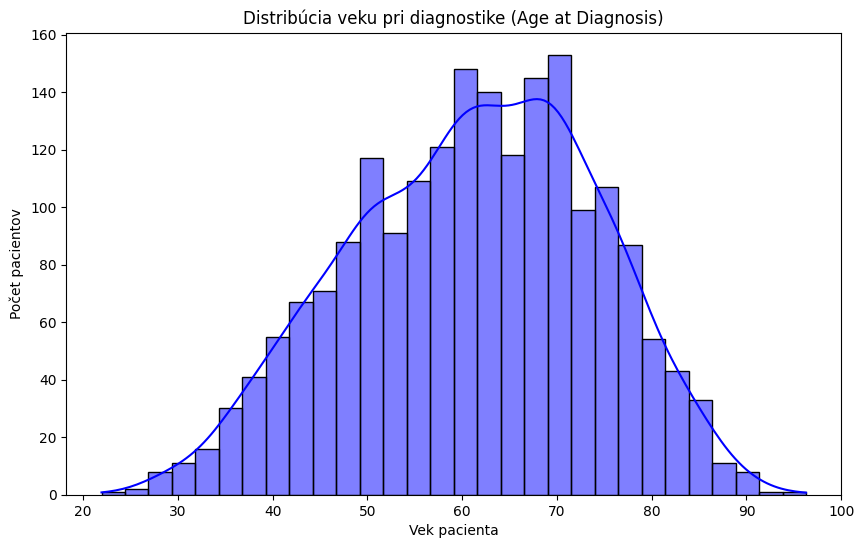

In [149]:
plt.figure(figsize=(10, 6))
sns.histplot(data['Age at Diagnosis'], kde=True, color='blue', bins=30)
plt.title('Distribúcia veku pri diagnostike (Age at Diagnosis)')
plt.xlabel('Vek pacienta')
plt.ylabel('Počet pacientov')
plt.show()


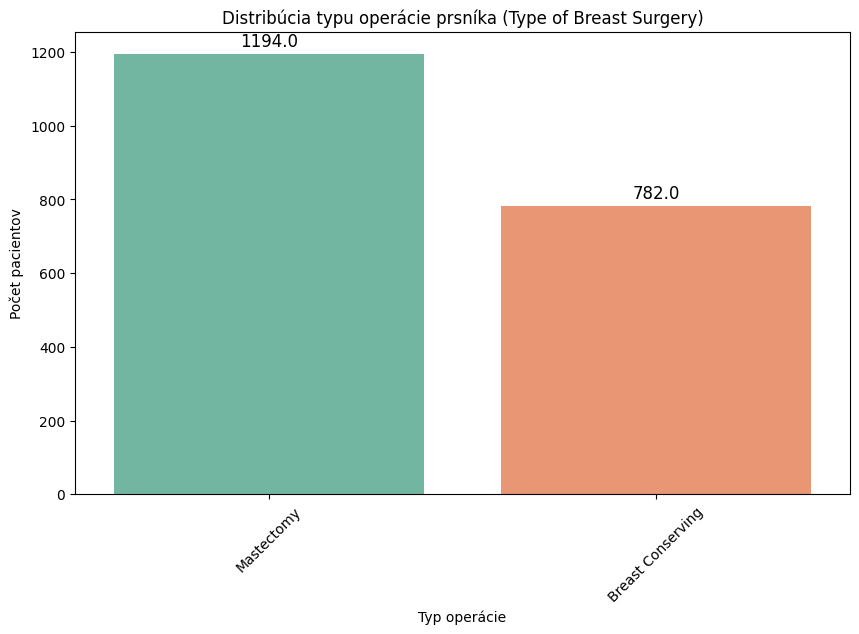

In [150]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Type of Breast Surgery', data=data, palette='Set2')
plt.title('Distribúcia typu operácie prsníka (Type of Breast Surgery)')
plt.xlabel('Typ operácie')
plt.ylabel('Počet pacientov')

for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height()}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center', 
                       fontsize=12, color='black', 
                       xytext=(0, 9), textcoords='offset points')

plt.xticks(rotation=45)
plt.show()


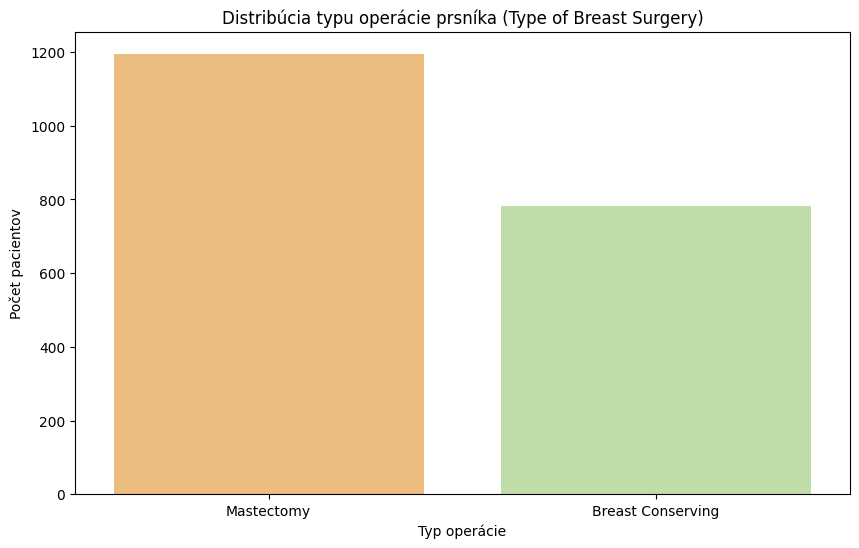

In [151]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Type of Breast Surgery', data=data, palette='Spectral')  # Použitie palety 'cubehelix'
plt.title('Distribúcia typu operácie prsníka (Type of Breast Surgery)')
plt.xlabel('Typ operácie')
plt.ylabel('Počet pacientov')

plt.show()


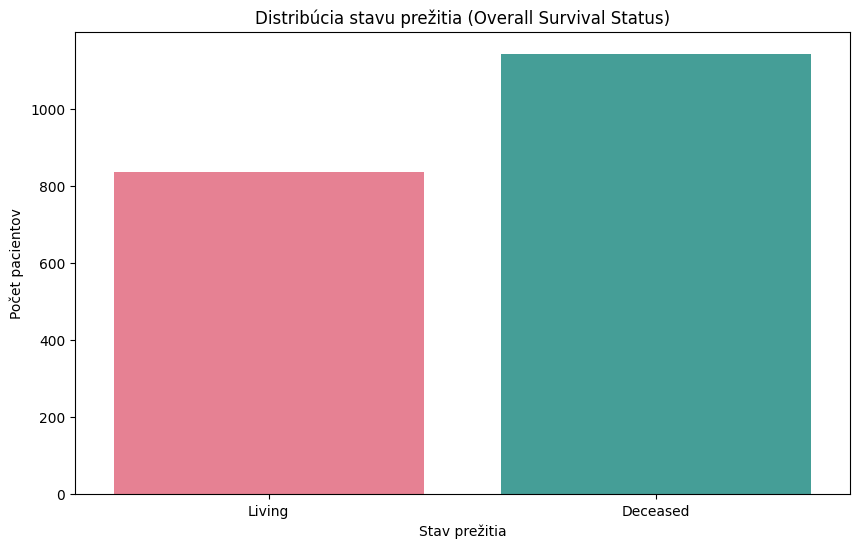

In [152]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Overall Survival Status', data=data, palette='husl')  # Zmena farieb na 'muted'
plt.title('Distribúcia stavu prežitia (Overall Survival Status)')
plt.xlabel('Stav prežitia')
plt.ylabel('Počet pacientov')

plt.show()


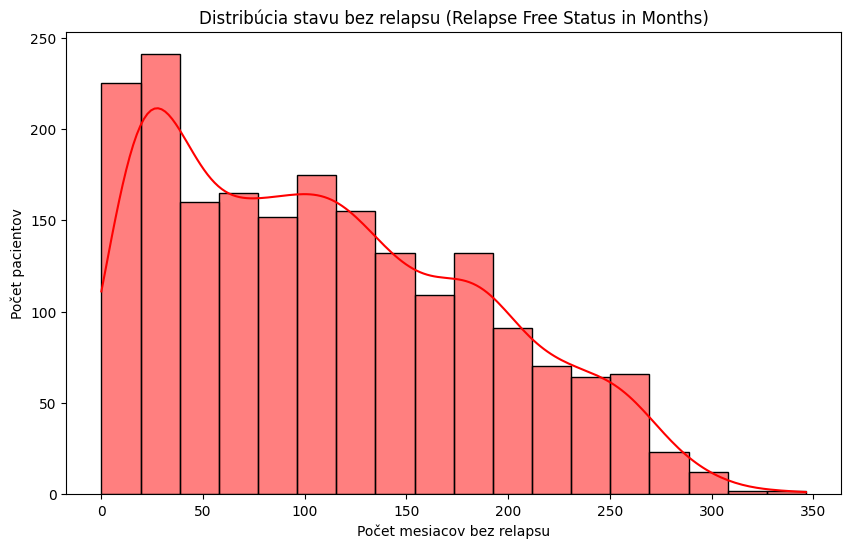

In [153]:
plt.figure(figsize=(10, 6))
sns.histplot(data['Relapse Free Status (Months)'], kde=True, color='red')  
plt.title('Distribúcia stavu bez relapsu (Relapse Free Status in Months)')
plt.xlabel('Počet mesiacov bez relapsu')
plt.ylabel('Počet pacientov')

plt.show()


### Kategorizacia - v nasledujucej casti sa zameriame na prevod kategorickych hodnot na numericke
##### Sucastou su rozme metody ako napriklad klasicke binarne kodovanie, transformacia ordinalit, one-hot encoding (dummy encoding)

In [154]:
unique_surgeries = data['Type of Breast Surgery'].unique()

# Výpis unikátnych hodnôt
print(unique_surgeries)

['Mastectomy' 'Breast Conserving']


In [155]:
cancer_type = data['Type of Breast Surgery'].value_counts()
print(cancer_type)

Type of Breast Surgery
Mastectomy           1194
Breast Conserving     782
Name: count, dtype: int64


In [156]:
#Pre túto premennú použijeme Binárne Kódovanie, nemôžem použiť, že jedno je 1 a druhé 2 lebo to by mohlo model zmiasť a interpretoval by si to ako ordinalitu, že jedna hodnota je viac
#Naopak ak použijem 0 a 1 to už je fajn lebo bude mať jasné, že ide o binárnu premennú, kde 0 znamené absenciu určitej vlastnosti
data['Type of Breast Surgery'] = np.uint8(data['Type of Breast Surgery'].map({'Breast Conserving': 0, 'Mastectomy':1 }))


In [157]:
cancer_type = data['Type of Breast Surgery'].value_counts()
print(cancer_type)

Type of Breast Surgery
1    1194
0     782
Name: count, dtype: int64


In [158]:
unique_surgeries = data['Cancer Type'].unique()

# Výpis unikátnych hodnôt
print(unique_surgeries)

['Breast Cancer' 'Breast Sarcoma']


In [159]:
cancer_type = data['Cancer Type'].value_counts()
print(cancer_type)

Cancer Type
Breast Cancer     1975
Breast Sarcoma       1
Name: count, dtype: int64


In [160]:
data['Cancer Type'] = np.uint8(data['Cancer Type'].map({'Breast Cancer': 0, 'Breast Sarcoma':1 }))


#### Dummy encoding a one-hot encoding sú dve podobné techniky na konverziu kategóriálnych premenných do numerického formátu, avšak s kľúčovým rozdielom. One-hot encoding vytvára samostatný binárny stĺpec pre každú kategóriu, pričom každá vzorka má hodnotu 1 v príslušnej kategórii a 0 inde. Dummy encoding je podobný, ale z n kategórií vytvorí n-1 stĺpcov, čím sa eliminuje jedna kategória ako referenčná, aby sa predišlo kolinearite v modeloch ako lineárna regresia.

In [161]:

unique_surgeries = data['Cancer Type Detailed'].unique()

# Výpis unikátnych hodnôt
print(unique_surgeries)

['Breast Invasive Ductal Carcinoma'
 'Breast Mixed Ductal and Lobular Carcinoma'
 'Breast Invasive Lobular Carcinoma' 'Invasive Breast Carcinoma'
 'Breast Invasive Mixed Mucinous Carcinoma' 'Breast']


In [162]:
# Dummy encoding 
dummies_cancer_type = pd.get_dummies(data['Cancer Type Detailed'], prefix='Cancer_Type', drop_first=True)

# Pripojenie nových stĺpcov
data = pd.concat([data, dummies_cancer_type], axis=1)

# Odstránenie pôvodného stĺpca
data = data.drop('Cancer Type Detailed', axis=1)
data.head()

,Patient ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,Cohort,ER status measured by IHC,ER Status,Neoplasm Histologic Grade,HER2 status measured by SNP6,HER2 Status,Tumor Other Histologic Subtype,Hormone Therapy,Inferred Menopausal State,Integrative Cluster,Primary Tumor Laterality,Lymph nodes examined positive,Mutation Count,Nottingham prognostic index,Oncotree Code,Overall Survival (Months),Overall Survival Status,PR Status,Radio Therapy,Relapse Free Status (Months),Relapse Free Status,Sex,3-Gene classifier subtype,Tumor Size,Tumor Stage,Patient's Vital Status,Cancer_Type_Breast Invasive Ductal Carcinoma,Cancer_Type_Breast Invasive Lobular Carcinoma,Cancer_Type_Breast Invasive Mixed Mucinous Carcinoma,Cancer_Type_Breast Mixed Ductal and Lobular Carcinoma,Cancer_Type_Invasive Breast Carcinoma
0,MB-0000,75.65,1,0,High,No,claudin-low,1.0,Positve,Positive,3.0,Neutral,Negative,Ductal/NST,Yes,Post,4ER+,Right,10.0,5.0,6.044,IDC,140.500000,Living,Negative,Yes,138.65,Not Recurred,Female,ER-/HER2-,22.0,2.0,Living,True,False,False,False,False
1,MB-0002,43.19,0,0,High,No,LumA,1.0,Positve,Positive,3.0,Neutral,Negative,Ductal/NST,Yes,Pre,4ER+,Right,0.0,2.0,4.020,IDC,84.633333,Living,Positive,Yes,83.52,Not Recurred,Female,ER+/HER2- High Prolif,10.0,1.0,Living,True,False,False,False,False
2,MB-0005,48.87,1,0,High,Yes,LumB,1.0,Positve,Positive,2.0,Neutral,Negative,Ductal/NST,Yes,Pre,3,Right,1.0,2.0,4.030,IDC,163.700000,Deceased,Positive,No,151.28,Recurred,Female,ER+/HER2- High Prolif,15.0,2.0,Died of Disease,True,False,False,False,False
3,MB-0006,47.68,1,0,Moderate,Yes,LumB,1.0,Positve,Positive,2.0,Neutral,Negative,Mixed,Yes,Pre,9,Right,3.0,1.0,4.050,MDLC,164.933333,Living,Positive,Yes,162.76,Not Recurred,Female,ER+/HER2- Low Prolif,25.0,2.0,Living,False,False,False,True,False
4,MB-0008,76.97,1,0,High,Yes,LumB,1.0,Positve,Positive,3.0,Neutral,Negative,Mixed,Yes,Post,9,Right,8.0,2.0,6.080,MDLC,41.366667,Deceased,Positive,Yes,18.55,Recurred,Female,ER+/HER2- High Prolif,40.0,2.0,Died of Disease,False,False,False,True,False


In [163]:
unique_surgeries = data['Cellularity'].unique()

# Výpis unikátnych hodnôt
print(unique_surgeries)

['High' 'Moderate' 'Low']


#### Keďže máme tri úrovne z hladiska atributu Cellularity pričom 3 je ako najagresívnejší typ rakoviny v porovnaní s ostatnými, tu zachováme ten ordinálny princíp  

In [164]:
data['Cellularity'] = np.uint8(data['Cellularity'].map({'High': 3, 'Moderate': 2, 'Low': 1}))

In [165]:
unique_surgeries = data['Chemotherapy'].unique()

# Výpis unikátnych hodnôt
print(unique_surgeries)

['No' 'Yes']


In [166]:
data['Chemotherapy'] = np.uint8(data['Chemotherapy'].map({'Yes': 1, 'No': 0}))


In [167]:
unique_surgeries = data['Pam50 + Claudin-low subtype'].unique()

# Výpis unikátnych hodnôt
print(unique_surgeries)

['claudin-low' 'LumA' 'LumB' 'Normal' 'Her2' 'Basal' 'NC']


In [168]:
# Dummy encoding 
dummies_subtype = pd.get_dummies(data['Pam50 + Claudin-low subtype'], prefix='Subtype', drop_first=True)

# Pripojenie nových stĺpcov k pôvodnému datasetu
data = pd.concat([data, dummies_subtype], axis=1)

# Odstránenie pôvodného stĺpca
data = data.drop('Pam50 + Claudin-low subtype', axis=1)
data.head()

,Patient ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cellularity,Chemotherapy,Cohort,ER status measured by IHC,ER Status,Neoplasm Histologic Grade,HER2 status measured by SNP6,HER2 Status,Tumor Other Histologic Subtype,Hormone Therapy,Inferred Menopausal State,Integrative Cluster,Primary Tumor Laterality,Lymph nodes examined positive,Mutation Count,Nottingham prognostic index,Oncotree Code,Overall Survival (Months),Overall Survival Status,PR Status,Radio Therapy,Relapse Free Status (Months),Relapse Free Status,Sex,3-Gene classifier subtype,Tumor Size,Tumor Stage,Patient's Vital Status,Cancer_Type_Breast Invasive Ductal Carcinoma,Cancer_Type_Breast Invasive Lobular Carcinoma,Cancer_Type_Breast Invasive Mixed Mucinous Carcinoma,Cancer_Type_Breast Mixed Ductal and Lobular Carcinoma,Cancer_Type_Invasive Breast Carcinoma,Subtype_Her2,Subtype_LumA,Subtype_LumB,Subtype_NC,Subtype_Normal,Subtype_claudin-low
0,MB-0000,75.65,1,0,3,0,1.0,Positve,Positive,3.0,Neutral,Negative,Ductal/NST,Yes,Post,4ER+,Right,10.0,5.0,6.044,IDC,140.500000,Living,Negative,Yes,138.65,Not Recurred,Female,ER-/HER2-,22.0,2.0,Living,True,False,False,False,False,False,False,False,False,False,True
1,MB-0002,43.19,0,0,3,0,1.0,Positve,Positive,3.0,Neutral,Negative,Ductal/NST,Yes,Pre,4ER+,Right,0.0,2.0,4.020,IDC,84.633333,Living,Positive,Yes,83.52,Not Recurred,Female,ER+/HER2- High Prolif,10.0,1.0,Living,True,False,False,False,False,False,True,False,False,False,False
2,MB-0005,48.87,1,0,3,1,1.0,Positve,Positive,2.0,Neutral,Negative,Ductal/NST,Yes,Pre,3,Right,1.0,2.0,4.030,IDC,163.700000,Deceased,Positive,No,151.28,Recurred,Female,ER+/HER2- High Prolif,15.0,2.0,Died of Disease,True,False,False,False,False,False,False,True,False,False,False
3,MB-0006,47.68,1,0,2,1,1.0,Positve,Positive,2.0,Neutral,Negative,Mixed,Yes,Pre,9,Right,3.0,1.0,4.050,MDLC,164.933333,Living,Positive,Yes,162.76,Not Recurred,Female,ER+/HER2- Low Prolif,25.0,2.0,Living,False,False,False,True,False,False,False,True,False,False,False
4,MB-0008,76.97,1,0,3,1,1.0,Positve,Positive,3.0,Neutral,Negative,Mixed,Yes,Post,9,Right,8.0,2.0,6.080,MDLC,41.366667,Deceased,Positive,Yes,18.55,Recurred,Female,ER+/HER2- High Prolif,40.0,2.0,Died of Disease,False,False,False,True,False,False,False,True,False,False,False


#### Atribút Cohort v kontexte zdravotnej starostlivosti, klinických štúdií alebo výskumu rakoviny obvykle označuje skupinu pacientov, ktorí zdieľajú spoločný charakteristiku alebo podmienku, často založenú na čase (ako napríklad čas diagnózy), liečebnej intervencii, alebo inom kritériu.

In [169]:
unique_surgeries = data['Cohort'].unique()

# Výpis unikátnych hodnôt
print(unique_surgeries)

[1. 2. 3. 5. 4.]


In [170]:
cohort_dtype = data['Cohort'].dtype
print("Dátový typ atribútu 'Cohort':", cohort_dtype)

Dátový typ atribútu 'Cohort': float64


In [171]:
unique_surgeries = data['ER status measured by IHC'].unique()

# Výpis unikátnych hodnôt
print(unique_surgeries)

['Positve' 'Negative']


### Tu pozor je to chyba lebo tento atribát môže nadobúdať aj hodnoty Positive aj Positve, ja budem predpokladať, že je to to isté.

In [172]:
value_counts = data['ER status measured by IHC'].value_counts()

# Zobrazenie výsledku
print(value_counts)

ER status measured by IHC
Positve     1538
Negative     438
Name: count, dtype: int64


In [173]:
# Oprava hodnôt a ich mapovanie
data['ER status measured by IHC'] = data['ER status measured by IHC'].replace('Positve', 'Positive')
data['ER status measured by IHC'] = np.uint8(data['ER status measured by IHC'].map({'Positive': 1, 'Negative': 0}))

# Kontrola výsledku
print(data['ER status measured by IHC'].value_counts())


ER status measured by IHC
1    1538
0     438
Name: count, dtype: int64


In [174]:
unique_surgeries = data['ER Status'].unique()

# Výpis unikátnych hodnôt
print(unique_surgeries)

['Positive' 'Negative']


In [175]:
data['ER Status'] = np.uint8(data['ER Status'].map({'Positive': 1, 'Negative': 0}))


In [176]:
unique_surgeries = data['Neoplasm Histologic Grade'].unique()

# Výpis unikátnych hodnôt
print(unique_surgeries)

[3. 2. 1.]


In [177]:
unique_surgeries = data['HER2 status measured by SNP6'].unique()

# Výpis unikátnych hodnôt
print(unique_surgeries)

['Neutral' 'Loss' 'Gain' 'Undef']


In [178]:
# Dummy encoding
dummies_her2 = pd.get_dummies(data['HER2 status measured by SNP6'], prefix='HER2_Status', drop_first=True)

# Spojenie s pôvodným DataFrame
data = pd.concat([data, dummies_her2], axis=1)

# Odstránenie pôvodného atribútu
data = data.drop('HER2 status measured by SNP6', axis=1)
data.head()

,Patient ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cellularity,Chemotherapy,Cohort,ER status measured by IHC,ER Status,Neoplasm Histologic Grade,HER2 Status,Tumor Other Histologic Subtype,Hormone Therapy,Inferred Menopausal State,Integrative Cluster,Primary Tumor Laterality,Lymph nodes examined positive,Mutation Count,Nottingham prognostic index,Oncotree Code,Overall Survival (Months),Overall Survival Status,PR Status,Radio Therapy,Relapse Free Status (Months),Relapse Free Status,Sex,3-Gene classifier subtype,Tumor Size,Tumor Stage,Patient's Vital Status,Cancer_Type_Breast Invasive Ductal Carcinoma,Cancer_Type_Breast Invasive Lobular Carcinoma,Cancer_Type_Breast Invasive Mixed Mucinous Carcinoma,Cancer_Type_Breast Mixed Ductal and Lobular Carcinoma,Cancer_Type_Invasive Breast Carcinoma,Subtype_Her2,Subtype_LumA,Subtype_LumB,Subtype_NC,Subtype_Normal,Subtype_claudin-low,HER2_Status_Loss,HER2_Status_Neutral,HER2_Status_Undef
0,MB-0000,75.65,1,0,3,0,1.0,1,1,3.0,Negative,Ductal/NST,Yes,Post,4ER+,Right,10.0,5.0,6.044,IDC,140.500000,Living,Negative,Yes,138.65,Not Recurred,Female,ER-/HER2-,22.0,2.0,Living,True,False,False,False,False,False,False,False,False,False,True,False,True,False
1,MB-0002,43.19,0,0,3,0,1.0,1,1,3.0,Negative,Ductal/NST,Yes,Pre,4ER+,Right,0.0,2.0,4.020,IDC,84.633333,Living,Positive,Yes,83.52,Not Recurred,Female,ER+/HER2- High Prolif,10.0,1.0,Living,True,False,False,False,False,False,True,False,False,False,False,False,True,False
2,MB-0005,48.87,1,0,3,1,1.0,1,1,2.0,Negative,Ductal/NST,Yes,Pre,3,Right,1.0,2.0,4.030,IDC,163.700000,Deceased,Positive,No,151.28,Recurred,Female,ER+/HER2- High Prolif,15.0,2.0,Died of Disease,True,False,False,False,False,False,False,True,False,False,False,False,True,False
3,MB-0006,47.68,1,0,2,1,1.0,1,1,2.0,Negative,Mixed,Yes,Pre,9,Right,3.0,1.0,4.050,MDLC,164.933333,Living,Positive,Yes,162.76,Not Recurred,Female,ER+/HER2- Low Prolif,25.0,2.0,Living,False,False,False,True,False,False,False,True,False,False,False,False,True,False
4,MB-0008,76.97,1,0,3,1,1.0,1,1,3.0,Negative,Mixed,Yes,Post,9,Right,8.0,2.0,6.080,MDLC,41.366667,Deceased,Positive,Yes,18.55,Recurred,Female,ER+/HER2- High Prolif,40.0,2.0,Died of Disease,False,False,False,True,False,False,False,True,False,False,False,False,True,False


In [179]:
unique_surgeries = data['HER2 Status'].unique()

# Výpis unikátnych hodnôt
print(unique_surgeries)

['Negative' 'Positive']


In [180]:
data['HER2 Status'] = np.uint8(data['HER2 Status'].map({'Positive': 1, 'Negative': 0}))


In [181]:
unique_surgeries = data['Tumor Other Histologic Subtype'].unique()

# Výpis unikátnych hodnôt
print(unique_surgeries)

['Ductal/NST' 'Mixed' 'Lobular' 'Tubular/ cribriform' 'Mucinous'
 'Medullary' 'Other']


In [182]:
# Dummy encoding
dummies_tumor = pd.get_dummies(data['Tumor Other Histologic Subtype'], prefix='Tumor_Subtype', drop_first=True)

# Pripojenie dummy premenných k pôvodnému datasetu
data = pd.concat([data, dummies_tumor], axis=1)

# Odstránenie pôvodného stĺpca
data = data.drop('Tumor Other Histologic Subtype', axis=1)

# Kontrola výsledku
data.head()


,Patient ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cellularity,Chemotherapy,Cohort,ER status measured by IHC,ER Status,Neoplasm Histologic Grade,HER2 Status,Hormone Therapy,Inferred Menopausal State,Integrative Cluster,Primary Tumor Laterality,Lymph nodes examined positive,Mutation Count,Nottingham prognostic index,Oncotree Code,Overall Survival (Months),Overall Survival Status,PR Status,Radio Therapy,Relapse Free Status (Months),Relapse Free Status,Sex,3-Gene classifier subtype,Tumor Size,Tumor Stage,Patient's Vital Status,Cancer_Type_Breast Invasive Ductal Carcinoma,Cancer_Type_Breast Invasive Lobular Carcinoma,Cancer_Type_Breast Invasive Mixed Mucinous Carcinoma,Cancer_Type_Breast Mixed Ductal and Lobular Carcinoma,Cancer_Type_Invasive Breast Carcinoma,Subtype_Her2,Subtype_LumA,Subtype_LumB,Subtype_NC,Subtype_Normal,Subtype_claudin-low,HER2_Status_Loss,HER2_Status_Neutral,HER2_Status_Undef,Tumor_Subtype_Lobular,Tumor_Subtype_Medullary,Tumor_Subtype_Mixed,Tumor_Subtype_Mucinous,Tumor_Subtype_Other,Tumor_Subtype_Tubular/ cribriform
0,MB-0000,75.65,1,0,3,0,1.0,1,1,3.0,0,Yes,Post,4ER+,Right,10.0,5.0,6.044,IDC,140.500000,Living,Negative,Yes,138.65,Not Recurred,Female,ER-/HER2-,22.0,2.0,Living,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False
1,MB-0002,43.19,0,0,3,0,1.0,1,1,3.0,0,Yes,Pre,4ER+,Right,0.0,2.0,4.020,IDC,84.633333,Living,Positive,Yes,83.52,Not Recurred,Female,ER+/HER2- High Prolif,10.0,1.0,Living,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False
2,MB-0005,48.87,1,0,3,1,1.0,1,1,2.0,0,Yes,Pre,3,Right,1.0,2.0,4.030,IDC,163.700000,Deceased,Positive,No,151.28,Recurred,Female,ER+/HER2- High Prolif,15.0,2.0,Died of Disease,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False
3,MB-0006,47.68,1,0,2,1,1.0,1,1,2.0,0,Yes,Pre,9,Right,3.0,1.0,4.050,MDLC,164.933333,Living,Positive,Yes,162.76,Not Recurred,Female,ER+/HER2- Low Prolif,25.0,2.0,Living,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False
4,MB-0008,76.97,1,0,3,1,1.0,1,1,3.0,0,Yes,Post,9,Right,8.0,2.0,6.080,MDLC,41.366667,Deceased,Positive,Yes,18.55,Recurred,Female,ER+/HER2- High Prolif,40.0,2.0,Died of Disease,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False


In [183]:
unique_surgeries = data['Hormone Therapy'].unique()

# Výpis unikátnych hodnôt
print(unique_surgeries)

['Yes' 'No']


In [184]:
data['Hormone Therapy'] = np.uint8(data['Hormone Therapy'].map({'Yes': 1, 'No': 0}))


In [185]:
unique_surgeries = data['Inferred Menopausal State'].unique()

# Výpis unikátnych hodnôt
print(unique_surgeries)

['Post' 'Pre']


In [186]:
data['Inferred Menopausal State'] = np.uint8(data['Inferred Menopausal State'].map({'Pre': 0, 'Post': 1}))


In [187]:
unique_surgeries = data['Integrative Cluster'].unique()

# Výpis unikátnych hodnôt
print(unique_surgeries)

['4ER+' '3' '9' '7' '4ER-' '5' '8' '10' '1' '2' '6']


In [188]:
# Početnosť jednotlivých hodnôt v atribúte 'Integrative Cluster'
value_counts = data['Integrative Cluster'].value_counts()

# Počet chýbajúcich hodnôt v atribúte 'Integrative Cluster'
missing_values = data['Integrative Cluster'].isnull().sum()

# Výpis výsledkov
print("Početnosť jednotlivých hodnôt:")
print(value_counts)
print("\nPočet chýbajúcich hodnôt:")
print(missing_values)

Početnosť jednotlivých hodnôt:
Integrative Cluster
8       300
3       290
4ER+    259
10      225
5       190
7       189
9       146
1       139
6        85
4ER-     81
2        72
Name: count, dtype: int64

Počet chýbajúcich hodnôt:
0


In [189]:
# Dummy encoding
integrative_cluster2 = pd.get_dummies(data['Integrative Cluster'], prefix='IC', drop_first=True)

# Spojenie s pôvodným DataFrame
data = pd.concat([data, integrative_cluster2], axis=1)

# Odstránenie pôvodného atribútu 'Integrative Cluster'
data = data.drop('Integrative Cluster', axis=1)
data.head()

,Patient ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cellularity,Chemotherapy,Cohort,ER status measured by IHC,ER Status,Neoplasm Histologic Grade,HER2 Status,Hormone Therapy,Inferred Menopausal State,Primary Tumor Laterality,Lymph nodes examined positive,Mutation Count,Nottingham prognostic index,Oncotree Code,Overall Survival (Months),Overall Survival Status,PR Status,Radio Therapy,Relapse Free Status (Months),Relapse Free Status,Sex,3-Gene classifier subtype,Tumor Size,Tumor Stage,Patient's Vital Status,Cancer_Type_Breast Invasive Ductal Carcinoma,Cancer_Type_Breast Invasive Lobular Carcinoma,Cancer_Type_Breast Invasive Mixed Mucinous Carcinoma,Cancer_Type_Breast Mixed Ductal and Lobular Carcinoma,Cancer_Type_Invasive Breast Carcinoma,Subtype_Her2,Subtype_LumA,Subtype_LumB,Subtype_NC,Subtype_Normal,Subtype_claudin-low,HER2_Status_Loss,HER2_Status_Neutral,HER2_Status_Undef,Tumor_Subtype_Lobular,Tumor_Subtype_Medullary,Tumor_Subtype_Mixed,Tumor_Subtype_Mucinous,Tumor_Subtype_Other,Tumor_Subtype_Tubular/ cribriform,IC_10,IC_2,IC_3,IC_4ER+,IC_4ER-,IC_5,IC_6,IC_7,IC_8,IC_9
0,MB-0000,75.65,1,0,3,0,1.0,1,1,3.0,0,1,1,Right,10.0,5.0,6.044,IDC,140.500000,Living,Negative,Yes,138.65,Not Recurred,Female,ER-/HER2-,22.0,2.0,Living,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
1,MB-0002,43.19,0,0,3,0,1.0,1,1,3.0,0,1,0,Right,0.0,2.0,4.020,IDC,84.633333,Living,Positive,Yes,83.52,Not Recurred,Female,ER+/HER2- High Prolif,10.0,1.0,Living,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
2,MB-0005,48.87,1,0,3,1,1.0,1,1,2.0,0,1,0,Right,1.0,2.0,4.030,IDC,163.700000,Deceased,Positive,No,151.28,Recurred,Female,ER+/HER2- High Prolif,15.0,2.0,Died of Disease,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
3,MB-0006,47.68,1,0,2,1,1.0,1,1,2.0,0,1,0,Right,3.0,1.0,4.050,MDLC,164.933333,Living,Positive,Yes,162.76,Not Recurred,Female,ER+/HER2- Low Prolif,25.0,2.0,Living,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
4,MB-0008,76.97,1,0,3,1,1.0,1,1,3.0,0,1,1,Right,8.0,2.0,6.080,MDLC,41.366667,Deceased,Positive,Yes,18.55,Recurred,Female,ER+/HER2- High Prolif,40.0,2.0,Died of Disease,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True


In [190]:
unique_surgeries = data['Primary Tumor Laterality'].unique()

# Výpis unikátnych hodnôt
print(unique_surgeries)

['Right' 'Left']


In [191]:
data['Primary Tumor Laterality'] = np.uint8(data['Primary Tumor Laterality'].map({'Rigth': 0, 'Left': 1}))


In [192]:
unique_surgeries = data['Lymph nodes examined positive'].unique()

# Výpis unikátnych hodnôt
print(unique_surgeries)

[10.  0.  1.  3.  8. 24.  4. 16.  5. 14.  6.  2.  9. 22.  7. 21. 13. 12.
 25. 41. 15. 11. 19. 17. 18. 23. 26. 20. 31. 33. 45.]


In [193]:
unique_surgeries = data['Mutation Count'].unique()

# Výpis unikátnych hodnôt
print(unique_surgeries)

[ 5.  2.  1.  4.  3.  7.  8. 11. 14.  9.  6. 13. 21. 10. 22. 12. 28. 16.
 23. 18. 26. 20. 24. 17. 15. 40. 46. 30. 19. 80.]


In [194]:
unique_surgeries = data['Nottingham prognostic index'].unique()

# Výpis unikátnych hodnôt
print(unique_surgeries)

[6.044   4.02    4.03    4.05    6.08    4.062   6.13    4.058   5.032
 3.056   3.044   2.042   5.038   6.072   4.066   3.046   4.072   3.058
 4.034   4.046   3.036   4.032   3.024   4.1     3.048   3.026   5.028
 4.11    5.06    3.042   4.078   3.068   5.08    4.14    4.036   4.09
 2.14    2.054   6.3     5.034   3.06    4.12    5.052   3.04    2.018
 3.07    4.026   3.028   6.048   2.034   3.16    5.044   5.07    4.06
 4.054   3.032   6.052   5.076   4.038   6.1     4.024   1.056   2.004
 4.044   2.046   1.046   4.028   5.054   6.104   5.048   3.078   3.052
 4.04    6.088   4.048   2.04    4.088   4.042   6.068   3.05    5.1
 6.096   2.026   6.038   5.042   6.056   6.036   4.076   5.05    2.02
 4.056   3.006   5.01    3.08    5.04    6.04    3.038   3.034   1.07
 1.06    6.07    2.092   2.022   1.028   4.022   6.      1.024   4.052
 1.054   5.062   5.106   6.066   1.      5.056   2.05    5.11    3.018
 1.05    5.046   6.058   6.02    2.038   2.094   3.066   1.036   5.064
 6.064   5.0

In [195]:
unique_surgeries = data['Oncotree Code'].unique()

# Výpis unikátnych hodnôt
print(unique_surgeries)

['IDC' 'MDLC' 'ILC' 'BRCA' 'IMMC' 'BREAST']


In [196]:
# Dummy encoding
dummies_oncotree = pd.get_dummies(data['Oncotree Code'], prefix='Oncotree_Code', drop_first=True)

# Spojenie s pôvodným DataFrame
data = pd.concat([data, dummies_oncotree], axis=1)

# Odstránenie pôvodného atribútu 'Oncotree Code'
data = data.drop('Oncotree Code', axis=1)
data.head()

,Patient ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cellularity,Chemotherapy,Cohort,ER status measured by IHC,ER Status,Neoplasm Histologic Grade,HER2 Status,Hormone Therapy,Inferred Menopausal State,Primary Tumor Laterality,Lymph nodes examined positive,Mutation Count,Nottingham prognostic index,Overall Survival (Months),Overall Survival Status,PR Status,Radio Therapy,Relapse Free Status (Months),Relapse Free Status,Sex,3-Gene classifier subtype,Tumor Size,Tumor Stage,Patient's Vital Status,Cancer_Type_Breast Invasive Ductal Carcinoma,Cancer_Type_Breast Invasive Lobular Carcinoma,Cancer_Type_Breast Invasive Mixed Mucinous Carcinoma,Cancer_Type_Breast Mixed Ductal and Lobular Carcinoma,Cancer_Type_Invasive Breast Carcinoma,Subtype_Her2,Subtype_LumA,Subtype_LumB,Subtype_NC,Subtype_Normal,Subtype_claudin-low,HER2_Status_Loss,HER2_Status_Neutral,HER2_Status_Undef,Tumor_Subtype_Lobular,Tumor_Subtype_Medullary,Tumor_Subtype_Mixed,Tumor_Subtype_Mucinous,Tumor_Subtype_Other,Tumor_Subtype_Tubular/ cribriform,IC_10,IC_2,IC_3,IC_4ER+,IC_4ER-,IC_5,IC_6,IC_7,IC_8,IC_9,Oncotree_Code_BREAST,Oncotree_Code_IDC,Oncotree_Code_ILC,Oncotree_Code_IMMC,Oncotree_Code_MDLC
0,MB-0000,75.65,1,0,3,0,1.0,1,1,3.0,0,1,1,0,10.0,5.0,6.044,140.500000,Living,Negative,Yes,138.65,Not Recurred,Female,ER-/HER2-,22.0,2.0,Living,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
1,MB-0002,43.19,0,0,3,0,1.0,1,1,3.0,0,1,0,0,0.0,2.0,4.020,84.633333,Living,Positive,Yes,83.52,Not Recurred,Female,ER+/HER2- High Prolif,10.0,1.0,Living,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
2,MB-0005,48.87,1,0,3,1,1.0,1,1,2.0,0,1,0,0,1.0,2.0,4.030,163.700000,Deceased,Positive,No,151.28,Recurred,Female,ER+/HER2- High Prolif,15.0,2.0,Died of Disease,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False
3,MB-0006,47.68,1,0,2,1,1.0,1,1,2.0,0,1,0,0,3.0,1.0,4.050,164.933333,Living,Positive,Yes,162.76,Not Recurred,Female,ER+/HER2- Low Prolif,25.0,2.0,Living,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True
4,MB-0008,76.97,1,0,3,1,1.0,1,1,3.0,0,1,1,0,8.0,2.0,6.080,41.366667,Deceased,Positive,Yes,18.55,Recurred,Female,ER+/HER2- High Prolif,40.0,2.0,Died of Disease,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True


In [197]:
unique_surgeries = data['Overall Survival (Months)'].unique()

# Výpis unikátnych hodnôt
print(unique_surgeries)

[140.5         84.63333333 163.7        ...  82.73333333 175.9666667
 201.9       ]


In [198]:

unique_surgeries = data['Overall Survival Status'].unique()

# Výpis unikátnych hodnôt
print(unique_surgeries)

['Living' 'Deceased']


In [199]:
data['Overall Survival Status'] = np.uint8(data['Overall Survival Status'].map({'Living': 0, 'Deceased': 1}))


In [200]:
unique_surgeries = data['PR Status'].unique()

# Výpis unikátnych hodnôt
print(unique_surgeries)

['Negative' 'Positive']


In [201]:
data['PR Status'] = np.uint8(data['PR Status'].map({'Positive': 1, 'Negative': 0}))


In [202]:
data['Radio Therapy'] = np.uint8(data['Radio Therapy'].map({'Yes': 1, 'No': 0}))


In [203]:
unique_surgeries = data['Relapse Free Status'].unique()

# Výpis unikátnych hodnôt
print(unique_surgeries)

['Not Recurred' 'Recurred']


In [204]:
data['Relapse Free Status'] = np.uint8(data['Relapse Free Status'].map({'Not Recurred': 0, 'Recurred': 1}))

In [205]:
unique_surgeries = data['Sex'].unique()

# Výpis unikátnych hodnôt
print(unique_surgeries)

['Female']


In [206]:
#pohlavie odstranime lebo v subore udajov mame len zeny
data.drop(columns=['Sex'], inplace=True)


In [207]:
unique_surgeries = data['3-Gene classifier subtype'].unique()

# Výpis unikátnych hodnôt
print(unique_surgeries)

['ER-/HER2-' 'ER+/HER2- High Prolif' 'ER+/HER2- Low Prolif' 'HER2+']


In [208]:
# Dummy encoding
dummies_classifier = pd.get_dummies(data['3-Gene classifier subtype'], prefix='3-GCS', drop_first=True)

# Pridanie nových stĺpcov do pôvodného dátového rámca
data = pd.concat([data, dummies_classifier], axis=1)

# Odstránenie pôvodného stĺpca
data = data.drop('3-Gene classifier subtype', axis=1)
data.head()

,Patient ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cellularity,Chemotherapy,Cohort,ER status measured by IHC,ER Status,Neoplasm Histologic Grade,HER2 Status,Hormone Therapy,Inferred Menopausal State,Primary Tumor Laterality,Lymph nodes examined positive,Mutation Count,Nottingham prognostic index,Overall Survival (Months),Overall Survival Status,PR Status,Radio Therapy,Relapse Free Status (Months),Relapse Free Status,Tumor Size,Tumor Stage,Patient's Vital Status,Cancer_Type_Breast Invasive Ductal Carcinoma,Cancer_Type_Breast Invasive Lobular Carcinoma,Cancer_Type_Breast Invasive Mixed Mucinous Carcinoma,Cancer_Type_Breast Mixed Ductal and Lobular Carcinoma,Cancer_Type_Invasive Breast Carcinoma,Subtype_Her2,Subtype_LumA,Subtype_LumB,Subtype_NC,Subtype_Normal,Subtype_claudin-low,HER2_Status_Loss,HER2_Status_Neutral,HER2_Status_Undef,Tumor_Subtype_Lobular,Tumor_Subtype_Medullary,Tumor_Subtype_Mixed,Tumor_Subtype_Mucinous,Tumor_Subtype_Other,Tumor_Subtype_Tubular/ cribriform,IC_10,IC_2,IC_3,IC_4ER+,IC_4ER-,IC_5,IC_6,IC_7,IC_8,IC_9,Oncotree_Code_BREAST,Oncotree_Code_IDC,Oncotree_Code_ILC,Oncotree_Code_IMMC,Oncotree_Code_MDLC,3-GCS_ER+/HER2- Low Prolif,3-GCS_ER-/HER2-,3-GCS_HER2+
0,MB-0000,75.65,1,0,3,0,1.0,1,1,3.0,0,1,1,0,10.0,5.0,6.044,140.500000,0,0,1,138.65,0,22.0,2.0,Living,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False
1,MB-0002,43.19,0,0,3,0,1.0,1,1,3.0,0,1,0,0,0.0,2.0,4.020,84.633333,0,1,1,83.52,0,10.0,1.0,Living,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False
2,MB-0005,48.87,1,0,3,1,1.0,1,1,2.0,0,1,0,0,1.0,2.0,4.030,163.700000,1,1,0,151.28,1,15.0,2.0,Died of Disease,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
3,MB-0006,47.68,1,0,2,1,1.0,1,1,2.0,0,1,0,0,3.0,1.0,4.050,164.933333,0,1,1,162.76,0,25.0,2.0,Living,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,True,False,False
4,MB-0008,76.97,1,0,3,1,1.0,1,1,3.0,0,1,1,0,8.0,2.0,6.080,41.366667,1,1,1,18.55,1,40.0,2.0,Died of Disease,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False


In [209]:
unique_surgeries = data['Tumor Size'].unique()

# Výpis unikátnych hodnôt
print(unique_surgeries)

[ 22.    10.    15.    25.    40.    31.    65.    29.    16.    28.
  21.    19.    36.    33.    23.    17.    18.    12.    50.    24.
  13.    14.    55.    30.    39.    34.    70.    45.    27.   150.
  60.    26.    20.     9.    35.    80.    38.     2.    52.    44.
  48.     3.     5.    46.    11.    53.    47.    32.    67.    43.
  42.   180.    57.     4.   100.    37.    90.     8.   160.    84.
 130.     5.5   62.     1.    49.    99.    68.     7.    41.     6.
  75.    51.   120.    61.    79.    71.    22.5   17.9   14.5   12.8
  18.5   15.5   21.5   16.9   24.4   12.5   40.3   11.8   32.6   17.2
  13.8   15.7  182.    85.    18.3   21.6   28.5   16.2    2.3   15.2
  31.1   14.3   12.6   25.1   17.6    2.12  21.3   22.32  17.7   15.47
  24.15  20.5 ]


In [210]:
unique_surgeries = data['Tumor Stage'].unique()

# Výpis unikátnych hodnôt
print(unique_surgeries)

[2. 1. 4. 3. 0.]


In [211]:
data.rename(columns={
    "Patient's Vital Status": "event_potencial",
    "Overall Survival (Months)": "time"
}, inplace=True)

In [212]:
data['event_potencial'].value_counts()


event_potencial
Living                  835
Died of Disease         645
Died of Other Causes    496
Name: count, dtype: int64

In [213]:
unique_surgeries = data['event_potencial'].unique()

# Výpis unikátnych hodnôt
print(unique_surgeries)

['Living' 'Died of Disease' 'Died of Other Causes']


In [214]:
# Replace values
data['event_potencial'] = data['event_potencial'].replace({
    'Living': 0,
    'Died of Disease': 1,
    'Died of Other Causes': 1
})

##### atribút event_potencial - čo je atribút Patient's Vital Status, ktorý som predpokladala, že bude kľúčový teraz vymažem, lebo tým, že som to zakódovala, že smrť z dôvodu rakoviny a smrť z iných dôvodov je stále smrť, to práve v sebe ukrýva atribút Overall Survival Status, on nerozlišuje či pacient zomrel z iných dôvodov alebo na rakovinu, proste keď zomrel tak hodnota sa rovna 1. V druhom analytickom procese sa ale zameriame na návrat k atribútu Patient's Vital Status a odstranime vsetkych pacientov, ktori zomreli z inych dovodov ako na rakovinu prsnika

In [215]:
data = data.drop('event_potencial', axis=1)


In [216]:
data.rename(columns={
    "Overall Survival Status": "event"
}, inplace=True)

In [217]:
data = data.drop(columns=['Patient ID'])


In [218]:
data.head()

,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cellularity,Chemotherapy,Cohort,ER status measured by IHC,ER Status,Neoplasm Histologic Grade,HER2 Status,Hormone Therapy,Inferred Menopausal State,Primary Tumor Laterality,Lymph nodes examined positive,Mutation Count,Nottingham prognostic index,time,event,PR Status,Radio Therapy,Relapse Free Status (Months),Relapse Free Status,Tumor Size,Tumor Stage,Cancer_Type_Breast Invasive Ductal Carcinoma,Cancer_Type_Breast Invasive Lobular Carcinoma,Cancer_Type_Breast Invasive Mixed Mucinous Carcinoma,Cancer_Type_Breast Mixed Ductal and Lobular Carcinoma,Cancer_Type_Invasive Breast Carcinoma,Subtype_Her2,Subtype_LumA,Subtype_LumB,Subtype_NC,Subtype_Normal,Subtype_claudin-low,HER2_Status_Loss,HER2_Status_Neutral,HER2_Status_Undef,Tumor_Subtype_Lobular,Tumor_Subtype_Medullary,Tumor_Subtype_Mixed,Tumor_Subtype_Mucinous,Tumor_Subtype_Other,Tumor_Subtype_Tubular/ cribriform,IC_10,IC_2,IC_3,IC_4ER+,IC_4ER-,IC_5,IC_6,IC_7,IC_8,IC_9,Oncotree_Code_BREAST,Oncotree_Code_IDC,Oncotree_Code_ILC,Oncotree_Code_IMMC,Oncotree_Code_MDLC,3-GCS_ER+/HER2- Low Prolif,3-GCS_ER-/HER2-,3-GCS_HER2+
0,75.65,1,0,3,0,1.0,1,1,3.0,0,1,1,0,10.0,5.0,6.044,140.500000,0,0,1,138.65,0,22.0,2.0,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False
1,43.19,0,0,3,0,1.0,1,1,3.0,0,1,0,0,0.0,2.0,4.020,84.633333,0,1,1,83.52,0,10.0,1.0,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False
2,48.87,1,0,3,1,1.0,1,1,2.0,0,1,0,0,1.0,2.0,4.030,163.700000,1,1,0,151.28,1,15.0,2.0,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
3,47.68,1,0,2,1,1.0,1,1,2.0,0,1,0,0,3.0,1.0,4.050,164.933333,0,1,1,162.76,0,25.0,2.0,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,True,False,False
4,76.97,1,0,3,1,1.0,1,1,3.0,0,1,1,0,8.0,2.0,6.080,41.366667,1,1,1,18.55,1,40.0,2.0,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False


In [219]:
print(data.isnull().sum())
data = data.dropna()


Age at Diagnosis                                         0
Type of Breast Surgery                                   0
Cancer Type                                              0
Cellularity                                              0
Chemotherapy                                             0
Cohort                                                   0
ER status measured by IHC                                0
ER Status                                                0
Neoplasm Histologic Grade                                0
HER2 Status                                              0
Hormone Therapy                                          0
Inferred Menopausal State                                0
Primary Tumor Laterality                                 0
Lymph nodes examined positive                            0
Mutation Count                                           0
Nottingham prognostic index                              0
time                                                    

In [220]:
data['event'].value_counts()


event
1    1141
0     835
Name: count, dtype: int64

In [132]:
# Exportovanie datasetu do CSV súboru
data.to_csv('final_dataset_PART1.csv', index=False)

print("Dataset bol úspešne exportovaný do final_dataset_PART1.csv")


Dataset bol úspešne exportovaný do final_dataset_PART1.csv


In [133]:
data =pd.read_csv("final_dataset_PART1.csv")

print(f'Dataset Shape: {data.shape}')
print(f' Dataset Memory Usage: {data.memory_usage().sum() / 1024 ** 2:.2f} MB')

Dataset Shape: (1976, 62)
 Dataset Memory Usage: 0.43 MB
